# This notebook demonstrates plotting the number density of MCS on a map
## It uses MCS track statistics file and counts each unique MCS located on a 1x1 degree grid once

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob, os
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import colormath, colormath.color_objects, colormath.color_conversions
from colormath.color_objects import sRGBColor
import urllib
import re
import colorcet as cc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from itertools import chain
import copy
import colorcet as cc
%matplotlib inline

In [2]:
# Sepcify directory of the MCS track stats file
rootdir = '/pscratch/sd/w/wcmca1/SCREAM-cess/'

# Specify the yearsf
years = [2019]
datetime_range = pd.to_datetime(['2019-09-01T00', '2020-09-01T00'])
lon_bounds = [-150,-40]
lat_bounds = [20,55]
lifetime_bounds = [4,80]

name_map1 = {'obs':'OBS', 'm1':'EAMxx-Nudged', 'm2':'EAMxx-Free'}
name_map2 = {'obs':'OBS', 'm1':'EAMxx-N', 'm2':'EAMxx-F'}

obsfiles = []
m1files = []
m2files = []
for yy in years:
    obsfiles = obsfiles + sorted(glob.glob(f'{rootdir}gpm/stats/mcs_tracks_final_{yy}*.nc'))
    m1files = m1files + sorted(glob.glob(f'{rootdir}control_nudged/stats/mcs_tracks_final_{yy}*.nc'))
    m2files = m2files + sorted(glob.glob(f'{rootdir}control_free/stats/mcs_tracks_final_{yy}*.nc'))
nyears_obs = len(obsfiles)
nyears_m1 = len(m1files)
nyears_m2 = len(m2files)
print(f'Number of years (OBS): {nyears_obs}')
print(f'Number of years (SCREAM-free): {nyears_m1}')
print(f'Number of years (SCREAM-nudged): {nyears_m2}')

# topfile = '/global/project/projectdirs/m1657/zfeng/SAAG/map_data/wrf_landmask_reg2imerg.nc'

figdir = f'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

Number of years (OBS): 1
Number of years (SCREAM-free): 1
Number of years (SCREAM-nudged): 1
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/


In [3]:
# import numpy as np
# import xarray as xr
# import pandas as pd
# import glob, os
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.gridspec as gridspec
# import cartopy
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# from itertools import chain
# import copy
# %matplotlib inline

In [4]:
obsfiles, m1files, m2files

(['/pscratch/sd/w/wcmca1/SCREAM-cess/gpm/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc'],
 ['/pscratch/sd/w/wcmca1/SCREAM-cess/control_nudged/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc'],
 ['/pscratch/sd/w/wcmca1/SCREAM-cess/control_free/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc'])

# Functions to count MCS on a grid

In [5]:
def get_unique_placements(track_num, lat, lon, ntimes):
    """
    Get unique pairs of lat/lon for a track
    """
    # Put all lat/lon pairs over each time for a track into an array
    this_row = np.array([[lat[track_num, tt], lon[track_num, tt]] for tt in range(0, ntimes)])
    # Return the unique pairs (axis=0)
    return np.array(np.unique(this_row, axis=0))

def count_unique_mcs(lat, lon, xbins, ybins):
    
    ntracks, ntimes = lat.shape

    # A function to loop over tracks
    get_unique = lambda D: get_unique_placements(D, lat, lon, ntimes)

    # Loop over each track and get the unique pairs of lat/lon
    all_uniques = list(map(get_unique, np.arange(0, ntracks)))

    # Flatten the list of lat/lon pairs (using chain), and convert into an array
    unique_latlon = np.array(list(chain(*all_uniques)))

    # Count number on map using histogram2d
    ranges = [[min(ybins), max(ybins)], [min(xbins), max(xbins)]]
    hist2d, yedges, xedges = np.histogram2d(unique_latlon[:,0], unique_latlon[:,1], bins=[ybins, xbins], range=ranges)

    return hist2d

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [6]:
def find_tracks_start(ds_in, load_data=False):
    """
    Find tracks within a period, region and lifetime bounds.
    """
    # Get the track start time, location, lifetime
    start_basetime = ds_in.start_basetime
    start_lon = ds_in.meanlon.isel(times=0)
    start_lat = ds_in.meanlat.isel(times=0)
    lifetime = ds_in.track_duration * ds_in.attrs['time_resolution_hour']
    
    # Load data into memory
    if load_data:
        ds_in.load()
        drop_vars = True
    else:
        drop_vars = False

    # Filter tracks that initiates within a time period, region and lifetime
    ds_out = ds_in.where(
        (start_basetime >= min(datetime_range)) & (start_basetime <= max(datetime_range)) & \
        (start_lon >= min(lon_bounds)) & (start_lon <= max(lon_bounds)) & \
        (start_lat >= min(lat_bounds)) & (start_lat <= max(lat_bounds)) & \
        (lifetime >= min(lifetime_bounds)) & (lifetime <= max(lifetime_bounds)),
        drop=drop_vars,
    )
    return ds_out

In [7]:
# # Read topography data
# dstop = xr.open_dataset(topfile)
# # Convert surface geopotential to height in meters
# ter = dstop.HGT.squeeze()
# landmask = dstop.LANDMASK.squeeze()
# ter_s = gaussian_filter(ter, 1)
# lon_ter = dstop.lon
# lat_ter = dstop.lat
# dstop

In [8]:
# Read OBS data
dsobs = xr.open_mfdataset(obsfiles, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_obs = dsobs.sizes['tracks']
dsobs['tracks'] = np.arange(0, ntracks_obs)

In [9]:
# Read m1 data
dsm1 = xr.open_mfdataset(m1files, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_m1 = dsm1.sizes['tracks']
dsm1['tracks'] = np.arange(0, ntracks_m1)

In [10]:
# Read m2 data
dsm2 = xr.open_mfdataset(m2files, concat_dim='tracks', combine='nested')
# Renumber the tracks so they are unique
ntracks_m2 = dsm2.sizes['tracks']
dsm2['tracks'] = np.arange(0, ntracks_m2)

In [11]:
# Define a lat/lon grid for counting MCS
lonmin, lonmax = -150., -40.1
latmin, latmax = 20., 60.1
xbins = np.arange(lonmin, lonmax, 1)
ybins = np.arange(latmin, latmax, 1)

In [12]:
datetime_range, lon_bounds, lat_bounds, lifetime_bounds

(DatetimeIndex(['2019-09-01', '2020-09-01'], dtype='datetime64[ns]', freq=None),
 [-150, -40],
 [20, 55],
 [4, 80])

## Filter tracks by time, region, lifetime

In [13]:
dsobs = find_tracks_start(dsobs, load_data=False)

In [14]:
dsm1 = find_tracks_start(dsm1, load_data=False)

In [15]:
dsm2 = find_tracks_start(dsm2, load_data=False)

In [16]:
# np.count_nonzero(np.isnan(dsobs_s.start_basetime))
# np.count_nonzero(np.isnan(dsobs_s.meanlon.isel(times=0)))

In [17]:
# Get track initial time valuees
base_time_obs = dsobs.base_time.load()
starttime_obs = base_time_obs.isel(times=0)
syear_obs = starttime_obs.dt.year.load()
season_obs = starttime_obs.dt.season.load()
start_split_cloudnumber_obs = dsobs.start_split_cloudnumber.load()
# nyears_obs = len(np.unique(syear_obs))
# print(f'Number of unique years (OBS): {nyears_obs}')
ntracks_obs = dsobs.sizes['tracks']
print(f'Number MCS (OBS): {ntracks_obs}')

Number MCS (OBS): 4730


In [18]:
# Get track initial time valuees
base_time_m1 = dsm1.base_time.load()
starttime_m1 = base_time_m1.isel(times=0)
syear_m1 = starttime_m1.dt.year.load()
season_m1 = starttime_m1.dt.season.load()
start_split_cloudnumber_m1 = dsm1.start_split_cloudnumber.load()
# nyears_m1 = len(np.unique(syear_m1))
# print(f'Number of unique years (m1): {nyears_m1}')
ntracks_m1 = dsm1.sizes['tracks']
print(f'Number MCS (m1): {ntracks_m1}')

Number MCS (m1): 3882


In [19]:
# Get track initial time valuees
base_time_m2 = dsm2.base_time.load()
starttime_m2 = base_time_m2.isel(times=0)
syear_m2 = starttime_m2.dt.year.load()
season_m2 = starttime_m2.dt.season.load()
start_split_cloudnumber_m2 = dsm2.start_split_cloudnumber.load()
# nyears_m2 = len(np.unique(syear_m2))
# print(f'Number of unique years (m2): {nyears_m2}')
ntracks_m2 = dsm2.sizes['tracks']
print(f'Number MCS (m2): {ntracks_m2}')

Number MCS (m2): 4905


In [20]:
# Round the lat/lon to the nearest integer, 
# This way the lat/lon are calculated at the precision of 1 degree (i.e., count on a 1x1 degree grid)
# Note: counting using histogram2d only works on 1x1 degree grid (unique lat/lon are round to integer)
rlat_obs = dsobs.meanlat.load().round()
rlon_obs = dsobs.meanlon.load().round()

rlat_m1 = dsm1.meanlat.load().round()
rlon_m1 = dsm1.meanlon.load().round()

rlat_m2 = dsm2.meanlat.load().round()
rlon_m2 = dsm2.meanlon.load().round()
# Convert m1 longitudes from 0~360 to -180~+180 to be consistent with OBS
# rlon_m1 = ((dsm1.meanlon.load().round() - 180) % 360) - 180

In [21]:
# Separate tracks by season
#rlat_obs_DJF = rlat_obs.where(season_obs == 'DJF', drop=True)
#rlon_obs_DJF = rlon_obs.where(season_obs == 'DJF', drop=True)
rlat_obs_MAM = rlat_obs.where(season_obs == 'MAM', drop=False)
rlon_obs_MAM = rlon_obs.where(season_obs == 'MAM', drop=False)
rlat_obs_JJA = rlat_obs.where(season_obs == 'JJA', drop=False)
rlon_obs_JJA = rlon_obs.where(season_obs == 'JJA', drop=False)
rlat_obs_SON = rlat_obs.where(season_obs == 'SON', drop=False)
rlon_obs_SON = rlon_obs.where(season_obs == 'SON', drop=False)

#rlat_m1_DJF = rlat_m1.where(season_m1 == 'DJF', drop=False)
#rlon_m1_DJF = rlon_m1.where(season_m1 == 'DJF', drop=False)
rlat_m1_MAM = rlat_m1.where(season_m1 == 'MAM', drop=False)
rlon_m1_MAM = rlon_m1.where(season_m1 == 'MAM', drop=False)
rlat_m1_JJA = rlat_m1.where(season_m1 == 'JJA', drop=False)
rlon_m1_JJA = rlon_m1.where(season_m1 == 'JJA', drop=False)
rlat_m1_SON = rlat_m1.where(season_m1 == 'SON', drop=False)
rlon_m1_SON = rlon_m1.where(season_m1 == 'SON', drop=False)

#rlat_m2_DJF = rlat_m2.where(season_m2 == 'DJF', drop=False)
#rlon_m2_DJF = rlon_m2.where(season_m2 == 'DJF', drop=False)
rlat_m2_MAM = rlat_m2.where(season_m2 == 'MAM', drop=False)
rlon_m2_MAM = rlon_m2.where(season_m2 == 'MAM', drop=False)
rlat_m2_JJA = rlat_m2.where(season_m2 == 'JJA', drop=False)
rlon_m2_JJA = rlon_m2.where(season_m2 == 'JJA', drop=False)
rlat_m2_SON = rlat_m2.where(season_m2 == 'SON', drop=False)
rlon_m2_SON = rlon_m2.where(season_m2 == 'SON', drop=False)

In [22]:
# Total MCS count
mcs_ircount_obs = count_unique_mcs(rlat_obs.values, rlon_obs.values, xbins, ybins)
mcs_ircount_m1 = count_unique_mcs(rlat_m1.values, rlon_m1.values, xbins, ybins)
mcs_ircount_m2 = count_unique_mcs(rlat_m2.values, rlon_m2.values, xbins, ybins)

In [23]:
# Total MCS count by season
#mcs_ircount_obs_DJF = count_unique_mcs(rlat_obs_DJF.values, rlon_obs_DJF.values, xbins, ybins)
mcs_ircount_obs_MAM = count_unique_mcs(rlat_obs_MAM.values, rlon_obs_MAM.values, xbins, ybins)
mcs_ircount_obs_JJA = count_unique_mcs(rlat_obs_JJA.values, rlon_obs_JJA.values, xbins, ybins)
mcs_ircount_obs_SON = count_unique_mcs(rlat_obs_SON.values, rlon_obs_SON.values, xbins, ybins)

In [24]:
#mcs_ircount_m1_DJF = count_unique_mcs(rlat_m1_DJF.values, rlon_m1_DJF.values, xbins, ybins)
mcs_ircount_m1_MAM = count_unique_mcs(rlat_m1_MAM.values, rlon_m1_MAM.values, xbins, ybins)
mcs_ircount_m1_JJA = count_unique_mcs(rlat_m1_JJA.values, rlon_m1_JJA.values, xbins, ybins)
mcs_ircount_m1_SON = count_unique_mcs(rlat_m1_SON.values, rlon_m1_SON.values, xbins, ybins)

In [25]:
#mcs_ircount_m2_DJF = count_unique_mcs(rlat_m2_DJF.values, rlon_m2_DJF.values, xbins, ybins)
mcs_ircount_m2_MAM = count_unique_mcs(rlat_m2_MAM.values, rlon_m2_MAM.values, xbins, ybins)
mcs_ircount_m2_JJA = count_unique_mcs(rlat_m2_JJA.values, rlon_m2_JJA.values, xbins, ybins)
mcs_ircount_m2_SON = count_unique_mcs(rlat_m2_SON.values, rlon_m2_SON.values, xbins, ybins)

In [26]:
# Divide by the number of years to get annual mean
mcs_irnumber_obs = mcs_ircount_obs / nyears_obs
mcs_irnumber_m1 = mcs_ircount_m1 / nyears_m1
mcs_irnumber_m2 = mcs_ircount_m2 / nyears_m2

In [27]:
#mcs_irnumber_obs_DJF = mcs_ircount_obs_DJF / nyears_obs
mcs_irnumber_obs_MAM = mcs_ircount_obs_MAM / nyears_obs
mcs_irnumber_obs_JJA = mcs_ircount_obs_JJA / nyears_obs
mcs_irnumber_obs_SON = mcs_ircount_obs_SON / nyears_obs

In [28]:
#mcs_irnumber_m1_DJF = mcs_ircount_m1_DJF / nyears_m1
mcs_irnumber_m1_MAM = mcs_ircount_m1_MAM / nyears_m1
mcs_irnumber_m1_JJA = mcs_ircount_m1_JJA / nyears_m1
mcs_irnumber_m1_SON = mcs_ircount_m1_SON / nyears_m1

In [29]:
#mcs_irnumber_m2_DJF = mcs_ircount_m2_DJF / nyears_m2
mcs_irnumber_m2_MAM = mcs_ircount_m2_MAM / nyears_m2
mcs_irnumber_m2_JJA = mcs_ircount_m2_JJA / nyears_m2
mcs_irnumber_m2_SON = mcs_ircount_m2_SON / nyears_m2

In [30]:
# Exclude split tracks [split cloudnumber = NaN]
lat0_obs = dsobs.meanlat.isel(times=0).where(np.isnan(start_split_cloudnumber_obs), drop=True)
lon0_obs = dsobs.meanlon.isel(times=0).where(np.isnan(start_split_cloudnumber_obs), drop=True)
lat0_m1 = dsm1.meanlat.isel(times=0).where(np.isnan(start_split_cloudnumber_m1), drop=True)
lon0_m1 = dsm1.meanlon.isel(times=0).where(np.isnan(start_split_cloudnumber_m1), drop=True)
lat0_m2 = dsm2.meanlat.isel(times=0).where(np.isnan(start_split_cloudnumber_m2), drop=True)
lon0_m2 = dsm2.meanlon.isel(times=0).where(np.isnan(start_split_cloudnumber_m2), drop=True)
# Convert [0-360] to [-180~+180]
# lon0_m1 = (lon0_m1 - 180) % 360 - 180

# Make a coarser resolution grid for initiation
xbins_c = np.arange(lonmin, lonmax, 3)
ybins_c = np.arange(latmin, latmax, 3)
ranges_c = [[min(ybins_c), max(ybins_c)], [min(xbins_c), max(xbins_c)]]
mcs_initcount_obs, yedges, xedges = np.histogram2d(lat0_obs, lon0_obs, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1, yedges, xedges = np.histogram2d(lat0_m1, lon0_m1, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m2, yedges, xedges = np.histogram2d(lat0_m2, lon0_m2, bins=[ybins_c, xbins_c], range=ranges_c)

mcs_initcount_obs = mcs_initcount_obs / nyears_obs
mcs_initcount_m1 = mcs_initcount_m1 / nyears_m1
mcs_initcount_m2 = mcs_initcount_m2 / nyears_m2

In [31]:
# Separate by season, exclude split tracks [split cloudnumber = NaN]
#lat0_obs_DJF = lat0_obs.where((season_obs == 'DJF') & np.isnan(start_split_cloudnumber_obs), drop=True)
#lon0_obs_DJF = lon0_obs.where((season_obs == 'DJF') & np.isnan(start_split_cloudnumber_obs), drop=True)
lat0_obs_MAM = lat0_obs.where((season_obs == 'MAM') & np.isnan(start_split_cloudnumber_obs), drop=True)
lon0_obs_MAM = lon0_obs.where((season_obs == 'MAM') & np.isnan(start_split_cloudnumber_obs), drop=True)
lat0_obs_JJA = lat0_obs.where((season_obs == 'JJA') & np.isnan(start_split_cloudnumber_obs), drop=True)
lon0_obs_JJA = lon0_obs.where((season_obs == 'JJA') & np.isnan(start_split_cloudnumber_obs), drop=True)
lat0_obs_SON = lat0_obs.where((season_obs == 'SON') & np.isnan(start_split_cloudnumber_obs), drop=True)
lon0_obs_SON = lon0_obs.where((season_obs == 'SON') & np.isnan(start_split_cloudnumber_obs), drop=True)

# For initiation, each MCS only has one pairs of lat/lon, so a 2D histogram works fine
#mcs_initcount_obs_DJF, yedges, xedges = np.histogram2d(lat0_obs_DJF, lon0_obs_DJF, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_MAM, yedges, xedges = np.histogram2d(lat0_obs_MAM, lon0_obs_MAM, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_JJA, yedges, xedges = np.histogram2d(lat0_obs_JJA, lon0_obs_JJA, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_SON, yedges, xedges = np.histogram2d(lat0_obs_SON, lon0_obs_SON, bins=[ybins_c, xbins_c], range=ranges_c)

#mcs_initcount_obs_DJF = mcs_initcount_obs_DJF / nyears_obs
mcs_initcount_obs_MAM = mcs_initcount_obs_MAM / nyears_obs
mcs_initcount_obs_JJA = mcs_initcount_obs_JJA / nyears_obs
mcs_initcount_obs_SON = mcs_initcount_obs_SON / nyears_obs

In [32]:
# Separate by season, exclude split tracks [split cloudnumber = NaN]
#lat0_m1_DJF = lat0_m1.where((season_m1 == 'DJF') & np.isnan(start_split_cloudnumber_m1), drop=True)
#lon0_m1_DJF = lon0_m1.where((season_m1 == 'DJF') & np.isnan(start_split_cloudnumber_m1), drop=True)
lat0_m1_MAM = lat0_m1.where((season_m1 == 'MAM') & np.isnan(start_split_cloudnumber_m1), drop=True)
lon0_m1_MAM = lon0_m1.where((season_m1 == 'MAM') & np.isnan(start_split_cloudnumber_m1), drop=True)
lat0_m1_JJA = lat0_m1.where((season_m1 == 'JJA') & np.isnan(start_split_cloudnumber_m1), drop=True)
lon0_m1_JJA = lon0_m1.where((season_m1 == 'JJA') & np.isnan(start_split_cloudnumber_m1), drop=True)
lat0_m1_SON = lat0_m1.where((season_m1 == 'SON') & np.isnan(start_split_cloudnumber_m1), drop=True)
lon0_m1_SON = lon0_m1.where((season_m1 == 'SON') & np.isnan(start_split_cloudnumber_m1), drop=True)

#mcs_initcount_m1_DJF, yedges, xedges = np.histogram2d(lat0_m1_DJF, lon0_m1_DJF, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_MAM, yedges, xedges = np.histogram2d(lat0_m1_MAM, lon0_m1_MAM, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_JJA, yedges, xedges = np.histogram2d(lat0_m1_JJA, lon0_m1_JJA, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_SON, yedges, xedges = np.histogram2d(lat0_m1_SON, lon0_m1_SON, bins=[ybins_c, xbins_c], range=ranges_c)

#mcs_initcount_m1_DJF = mcs_initcount_m1_DJF / nyears_m1
mcs_initcount_m1_MAM = mcs_initcount_m1_MAM / nyears_m1
mcs_initcount_m1_JJA = mcs_initcount_m1_JJA / nyears_m1
mcs_initcount_m1_SON = mcs_initcount_m1_SON / nyears_m1

In [33]:
# Separate by season, exclude split tracks [split cloudnumber = NaN]
#lat0_m2_DJF = lat0_m2.where((season_m2 == 'DJF') & np.isnan(start_split_cloudnumber_m2), drop=True)
#lon0_m2_DJF = lon0_m2.where((season_m2 == 'DJF') & np.isnan(start_split_cloudnumber_m2), drop=True)
lat0_m2_MAM = lat0_m2.where((season_m2 == 'MAM') & np.isnan(start_split_cloudnumber_m2), drop=True)
lon0_m2_MAM = lon0_m2.where((season_m2 == 'MAM') & np.isnan(start_split_cloudnumber_m2), drop=True)
lat0_m2_JJA = lat0_m2.where((season_m2 == 'JJA') & np.isnan(start_split_cloudnumber_m2), drop=True)
lon0_m2_JJA = lon0_m2.where((season_m2 == 'JJA') & np.isnan(start_split_cloudnumber_m2), drop=True)
lat0_m2_SON = lat0_m2.where((season_m2 == 'SON') & np.isnan(start_split_cloudnumber_m2), drop=True)
lon0_m2_SON = lon0_m2.where((season_m2 == 'SON') & np.isnan(start_split_cloudnumber_m2), drop=True)

#mcs_initcount_m2_DJF, yedges, xedges = np.histogram2d(lat0_m2_DJF, lon0_m2_DJF, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m2_MAM, yedges, xedges = np.histogram2d(lat0_m2_MAM, lon0_m2_MAM, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m2_JJA, yedges, xedges = np.histogram2d(lat0_m2_JJA, lon0_m2_JJA, bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m2_SON, yedges, xedges = np.histogram2d(lat0_m2_SON, lon0_m2_SON, bins=[ybins_c, xbins_c], range=ranges_c)

#mcs_initcount_m2_DJF = mcs_initcount_m2_DJF / nyears_m2
mcs_initcount_m2_MAM = mcs_initcount_m2_MAM / nyears_m2
mcs_initcount_m2_JJA = mcs_initcount_m2_JJA / nyears_m2
mcs_initcount_m2_SON = mcs_initcount_m2_SON / nyears_m2

In [38]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.5,1,1.5,2,3,4,5,6,8,10,14]
# # cmap = copy.copy(mpl.cm.get_cmap("Spectral_r"))
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_initcount_diff_JJA = mcs_initcount_m1_JJA - mcs_initcount_obs_JJA
# pm1 = ax[0].pcolormesh(xbins_c, ybins_c, mcs_initcount_obs_JJA, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins_c, ybins_c, mcs_initcount_m1_JJA, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins_c, ybins_c, mcs_initcount_diff_JJA, shading='auto', vmin=-5, vmax=5, cmap='RdBu_r')
# plt.colorbar(pm1, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [39]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.5,1,1.5,2,3,4,5,6,8,10,14]
# # cmap = copy.copy(mpl.cm.get_cmap("Spectral_r"))
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_initcount_diff_JJA = mcs_initcount_m2_JJA - mcs_initcount_obs_JJA
# pm2 = ax[0].pcolormesh(xbins_c, ybins_c, mcs_initcount_obs_JJA, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins_c, ybins_c, mcs_initcount_m2_JJA, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins_c, ybins_c, mcs_initcount_diff_JJA, shading='auto', vmin=-5, vmax=5, cmap='RdBu_r')
# plt.colorbar(pm2, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [40]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# #levels = [2,3,5,7,9,12,15,20,30,40,60]
# levels = [1,2,3,4,5,6,8,10,12,15,20]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_initcount_diff = mcs_initcount_m1 - mcs_initcount_obs
# pm1 = ax[0].pcolormesh(xbins_c, ybins_c, mcs_initcount_obs, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins_c, ybins_c, mcs_initcount_m1, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins_c, ybins_c, mcs_initcount_diff, shading='auto', vmin=-10, vmax=10, cmap='RdBu_r')
# plt.colorbar(pm1, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [41]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# #levels = [2,3,5,7,9,12,15,20,30,40,60]
# levels = [1,2,3,4,5,6,8,10,12,15,20]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_initcount_diff = mcs_initcount_m2 - mcs_initcount_obs
# pm2 = ax[0].pcolormesh(xbins_c, ybins_c, mcs_initcount_obs, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins_c, ybins_c, mcs_initcount_m2, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins_c, ybins_c, mcs_initcount_diff, shading='auto', vmin=-10, vmax=10, cmap='RdBu_r')
# plt.colorbar(pm2, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [42]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# #levels = [2,3,5,7,9,12,15,20,30,40,50,60]
# levels = [1,2,3,4,5,6,7,8,10,12,14,16,20]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff = mcs_irnumber_m1 - mcs_irnumber_obs
# pm1 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m1, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff, shading='auto', vmin=-8, vmax=8, cmap='RdBu_r')
# plt.colorbar(pm1, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [43]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# #levels = [2,3,5,7,9,12,15,20,30,40,50,60]
# levels = [1,2,3,4,5,6,7,8,10,12,14,16,20]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff = mcs_irnumber_m2 - mcs_irnumber_obs
# pm2 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m2, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff, shading='auto', vmin=-8, vmax=8, cmap='RdBu_r')
# plt.colorbar(pm2, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [44]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.2,0.5,1,1.5,2,3,4,5,6,8]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff_MAM = mcs_irnumber_m1_MAM - mcs_irnumber_obs_MAM
# pm1 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs_MAM, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m1_MAM, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff_MAM, shading='auto', vmin=-4, vmax=4, cmap='RdBu_r')
# plt.colorbar(pm1, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [45]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.2,0.5,1,1.5,2,3,4,5,6,8]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff_MAM = mcs_irnumber_m2_MAM - mcs_irnumber_obs_MAM
# pm2 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs_MAM, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m2_MAM, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff_MAM, shading='auto', vmin=-4, vmax=4, cmap='RdBu_r')
# plt.colorbar(pm2, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [46]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.2,0.5,1,1.5,2,3,4,5,6,8,10,15]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff_JJA = mcs_irnumber_m1_JJA - mcs_irnumber_obs_JJA
# pm1 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs_JJA, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m1_JJA, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff_JJA, shading='auto', vmin=-10, vmax=10, cmap='RdBu_r')
# plt.colorbar(pm1, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

In [47]:
# fig, ax = plt.subplots(ncols=3, figsize=[16,4], dpi=100)
# levels = [0.2,0.5,1,1.5,2,3,4,5,6,8,10,15]
# cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
# mcs_irnumber_diff_JJA = mcs_irnumber_m2_JJA - mcs_irnumber_obs_JJA
# pm2 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs_JJA, shading='auto', norm=norm, cmap=cmap)
# pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m2_JJA, shading='auto', norm=norm, cmap=cmap)
# pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff_JJA, shading='auto', vmin=-10, vmax=10, cmap='RdBu_r')
# plt.colorbar(pm2, ax=ax[0])
# plt.colorbar(pm2, ax=ax[1])
# plt.colorbar(pm3, ax=ax[2])
# fig.tight_layout()

## Function to plot maps (M x N)

In [48]:
def plot_maps_mxn(nrow, ncol, da, lon, lat, titles, levels, cmaps, cblabels, cbticks, figname, 
                  oob_colors=None, contourf=False, figsize=None, fontsize=None, cb_fontsize=None, show_cb2=False, figtitle=None,
                  map_extent=None, lonv=None, latv=None, label_lon=None, label_lat=None):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'

    # map_extent = [-150., -50., -20., 60.]
    # lonv = np.arange(-150,-50.1,20)
    # latv = np.arange(20,60.1,5)
    proj = ccrs.PlateCarree(central_longitude=0)
    data_proj = ccrs.PlateCarree()
    resolution = '50m'
    land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)
    states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)
    levelshgt = [1000,10000]

    fig = plt.figure(figsize=figsize, dpi=100)
    # Set up panels (nrow x ncol)
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    wspace = None
    hspace = None
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            Var = da[row][col]
            if (Var is not None):
                # Setup two columns (left: plot, right: colorbar)
                gss = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row,col], height_ratios=[1], width_ratios=[1,0.02], wspace=0.02, hspace=0.)
                ax = plt.subplot(gss[0], projection=proj)
                ax.set_extent(map_extent, crs=proj)
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.add_feature(states, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                ax.set_title(titles[row][col], loc='left')
                # Grid lines & labels
                gl = ax.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.5)
                gl.top_labels = False
                gl.right_labels = False
                gl.xlocator = mpl.ticker.FixedLocator(lonv)
                gl.ylocator = mpl.ticker.FixedLocator(latv)
                lon_formatter = LongitudeFormatter(zero_direction_label=True)
                lat_formatter = LatitudeFormatter()
                if (label_lon is not None):
                    if (label_lon[row][col]):
                        ax.set_xticks(lonv, crs=data_proj)
                        ax.xaxis.set_major_formatter(lon_formatter)
                if (label_lat is not None):
                    if (label_lat[row][col]):
                        ax.set_yticks(latv, crs=data_proj)
                        ax.yaxis.set_major_formatter(lat_formatter)

                # Terrain height
    #             ct = ax.contour(lon_ter, lat_ter, ter_s, levels=levelshgt, \
    #                             colors='dimgray', linewidths=0.5, transform=data_proj, zorder=3)

                # Select and mask data source
                Zm = np.ma.masked_where(np.isnan(Var), Var)
                lev = levels[row][col]
                cmap = copy.copy(mpl.colormaps.get_cmap(cmaps[row][col]))
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors[row][col]
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                norm = colors.BoundaryNorm(boundaries=lev, ncolors=cmap.N)
                # Plot data
                if (contourf == False):
                    cf1 = ax.pcolormesh(lon, lat, Zm, shading='auto', norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                else:
                    cf1 = ax.contourf(lon, lat, Zm, levels=levels, norm=norm, cmap=cmap, transform=data_proj, extend='both', zorder=2)

                # Colorbar
                cax = plt.subplot(gss[1])
                cbar = plt.colorbar(cf1, cax=cax, label=cblabels[row][col], ticks=cbticks[row][col], orientation='vertical', extend='both')
                cbar.ax.tick_params(labelsize=cb_fontsize)
#     # Suptitle
#     fig.suptitle(figtitle, y=0.92)
    
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

In [50]:
years = f'{syear_obs.min().item():.0f}-{syear_obs.max().item():.0f}'
years

'2019-2020'

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irnumber_map_annual_2019-2020.png


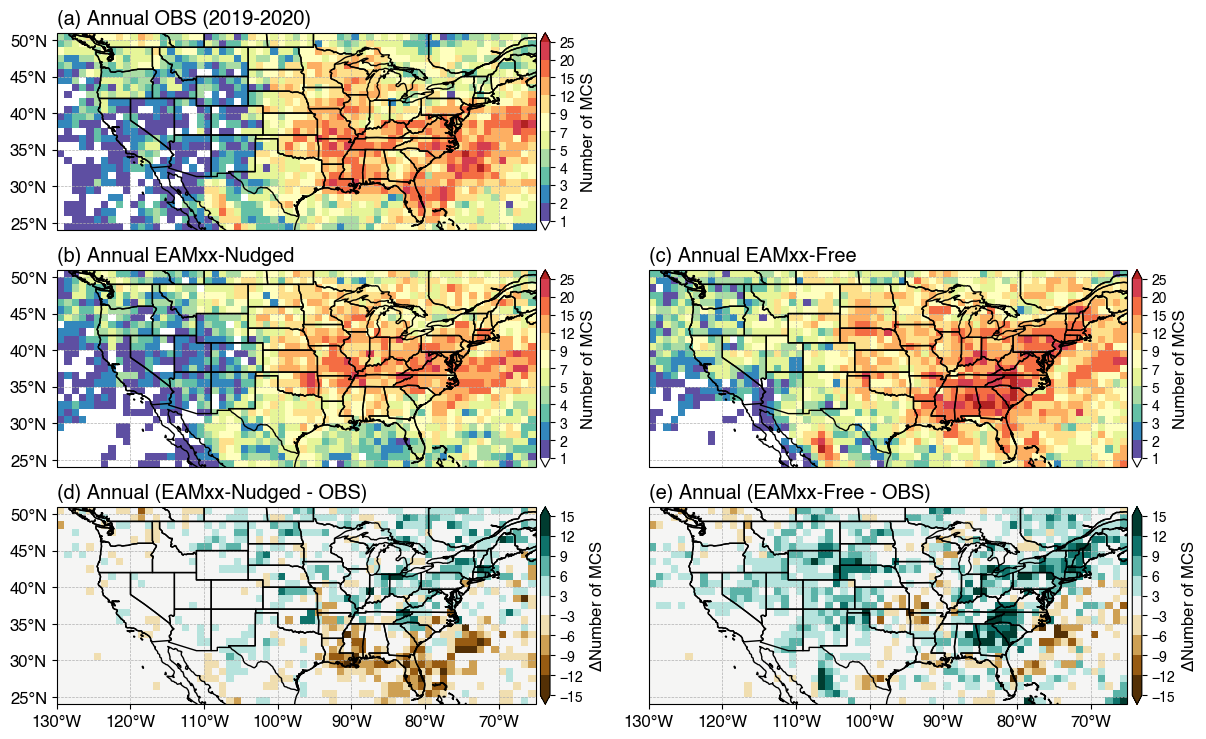

In [52]:
season = 'Annual'
mcs_irnumber_diff1 = mcs_irnumber_m1 - mcs_irnumber_obs
mcs_irnumber_diff2 = mcs_irnumber_m2 - mcs_irnumber_obs
dataarray = [
    [mcs_irnumber_obs, None],
    [mcs_irnumber_m1, mcs_irnumber_m2],
    [mcs_irnumber_diff1, mcs_irnumber_diff2],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,7,9,12,15,20,25]
lev2 = np.arange(-15,15.1,3)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.9)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS']*ncol,['Number of MCS']*ncol,[r'$\Delta$'+'Number of MCS']*ncol]
cbticks = levels
figname = f"{figdir}map_obs_scream_mcs_irnumber_map_annual_{years}.png"
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
# oob_colors = None
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins, ybins, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irnumber_map_annual_MAM_2019-2020.png


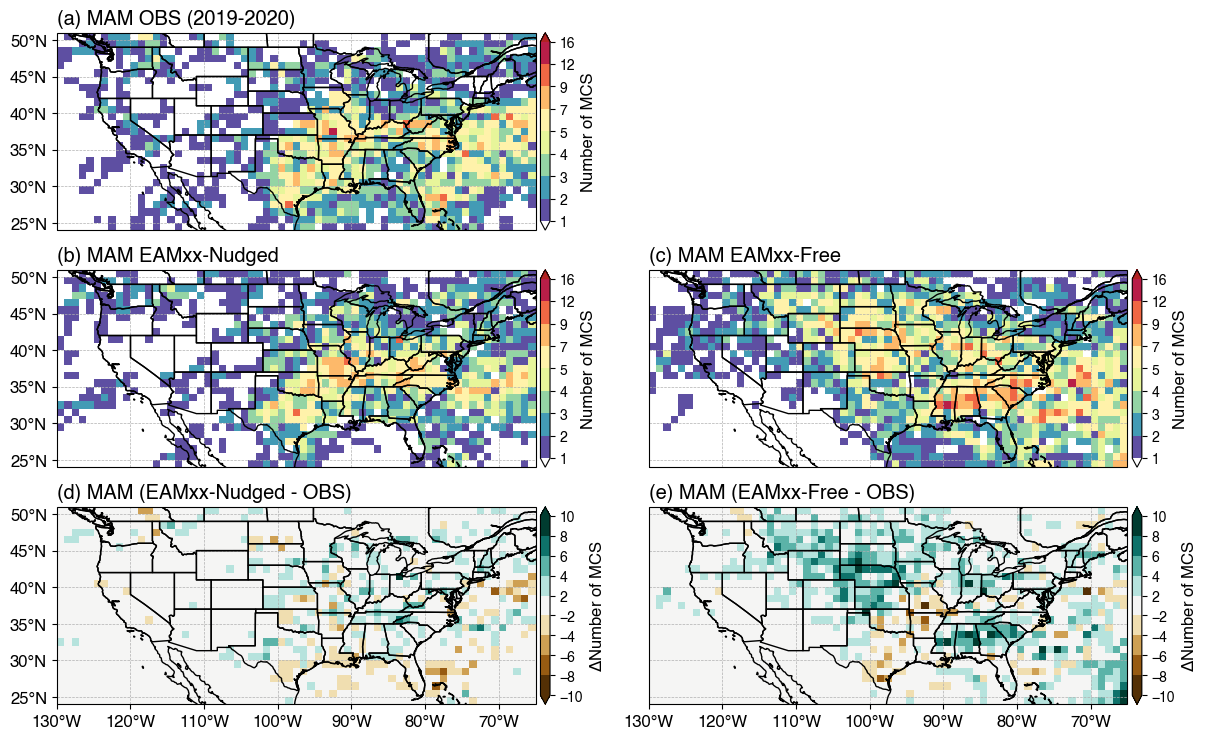

In [53]:
season = 'MAM'
mcs_irnumber_diff1_MAM = mcs_irnumber_m1_MAM - mcs_irnumber_obs_MAM
mcs_irnumber_diff2_MAM = mcs_irnumber_m2_MAM - mcs_irnumber_obs_MAM
dataarray = [
    [mcs_irnumber_obs_MAM, None],
    [mcs_irnumber_m1_MAM, mcs_irnumber_m2_MAM],
    [mcs_irnumber_diff1_MAM, mcs_irnumber_diff2_MAM],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,7,9,12,16]
lev2 = np.arange(-10,10.1,2)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.95)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS']*ncol,['Number of MCS']*ncol,[r'$\Delta$'+'Number of MCS']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irnumber_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins, ybins, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irnumber_map_annual_JJA_2019-2020.png


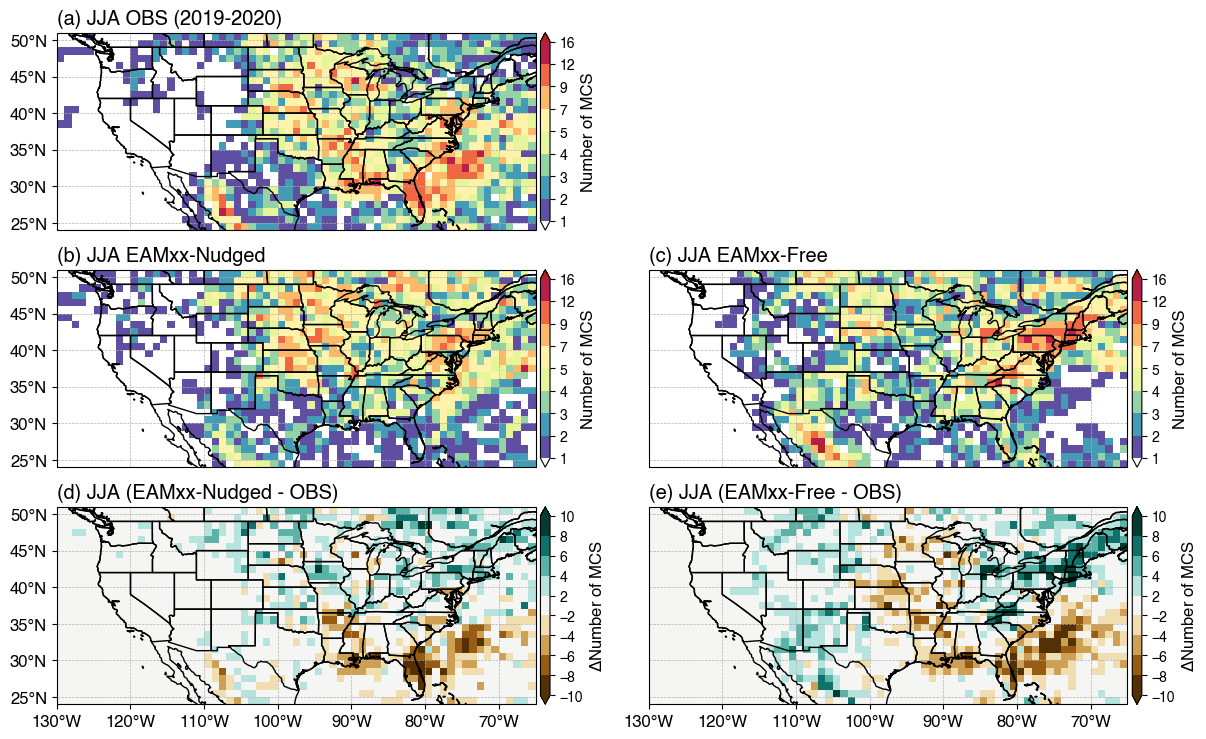

In [54]:
season = 'JJA'
mcs_irnumber_diff1_JJA = mcs_irnumber_m1_JJA - mcs_irnumber_obs_JJA
mcs_irnumber_diff2_JJA = mcs_irnumber_m2_JJA - mcs_irnumber_obs_JJA
dataarray = [
    [mcs_irnumber_obs_JJA, None],
    [mcs_irnumber_m1_JJA, mcs_irnumber_m2_JJA],
    [mcs_irnumber_diff1_JJA, mcs_irnumber_diff2_JJA],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,7,9,12,16]
lev2 = np.arange(-10,10.1,2)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.95)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS']*ncol,['Number of MCS']*ncol,[r'$\Delta$'+'Number of MCS']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irnumber_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins, ybins, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irnumber_map_annual_SON_2019-2020.png


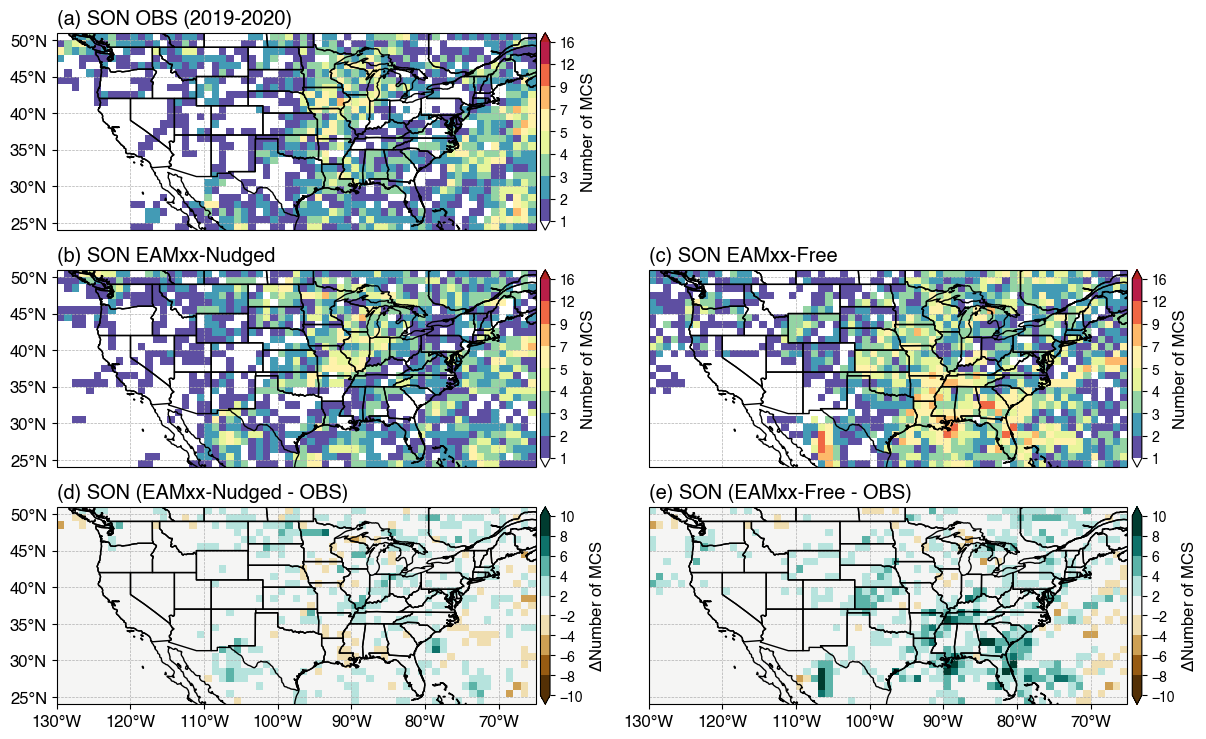

In [55]:
season = 'SON'
mcs_irnumber_diff1_SON = mcs_irnumber_m1_SON - mcs_irnumber_obs_SON
mcs_irnumber_diff2_SON = mcs_irnumber_m2_SON - mcs_irnumber_obs_SON
dataarray = [
    [mcs_irnumber_obs_SON, None],
    [mcs_irnumber_m1_SON, mcs_irnumber_m2_SON],
    [mcs_irnumber_diff1_SON, mcs_irnumber_diff2_SON],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,7,9,12,16]
lev2 = np.arange(-10,10.1,2)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.95)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS']*ncol,['Number of MCS']*ncol,[r'$\Delta$'+'Number of MCS']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irnumber_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins, ybins, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irinitiation_map_annual_2019-2020.png


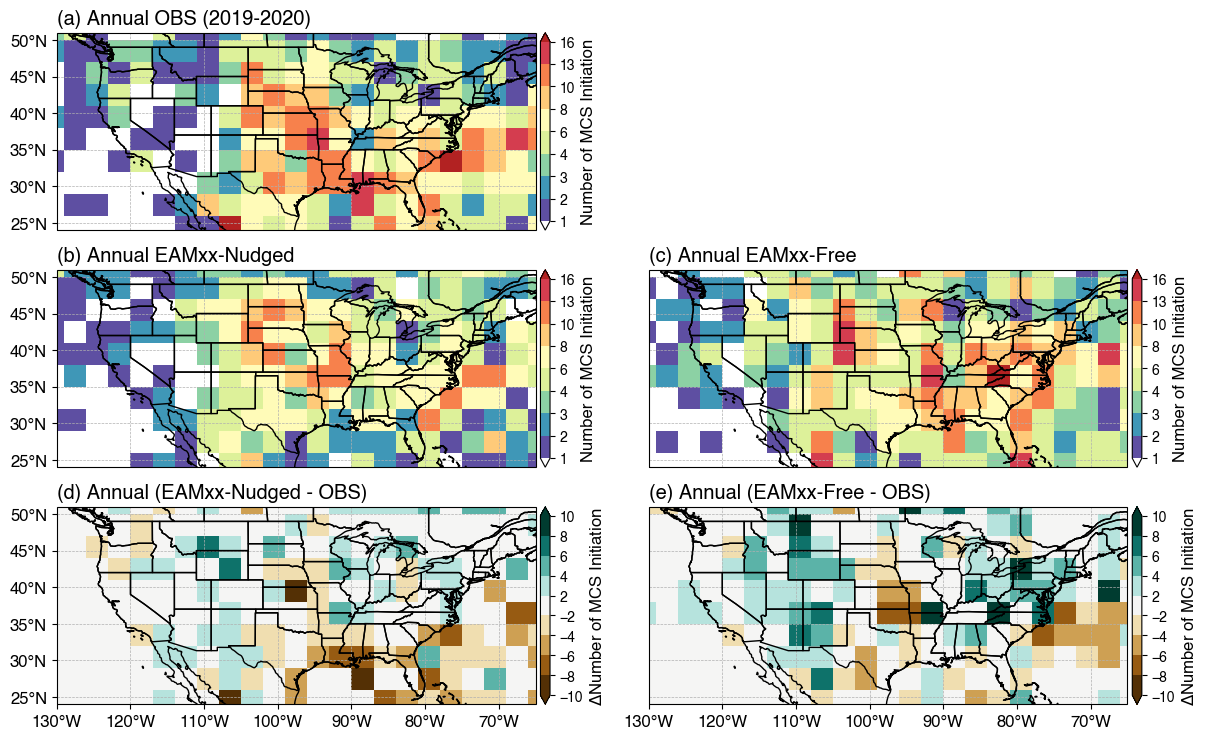

In [56]:
season = 'Annual'
mcs_initcount_diff1 = mcs_initcount_m1 - mcs_initcount_obs
mcs_initcount_diff2 = mcs_initcount_m2 - mcs_initcount_obs
dataarray = [
    [mcs_initcount_obs, None],
    [mcs_initcount_m1, mcs_initcount_m2],
    [mcs_initcount_diff1, mcs_initcount_diff2],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,6,8,10,13,16]
lev2 = np.arange(-10,10.1,2)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.9)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS Initiation']*ncol,['Number of MCS Initiation']*ncol,[r'$\Delta$'+'Number of MCS Initiation']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irinitiation_map_annual_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
# oob_colors = None
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins_c, ybins_c, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irinitiation_map_annual_MAM_2019-2020.png


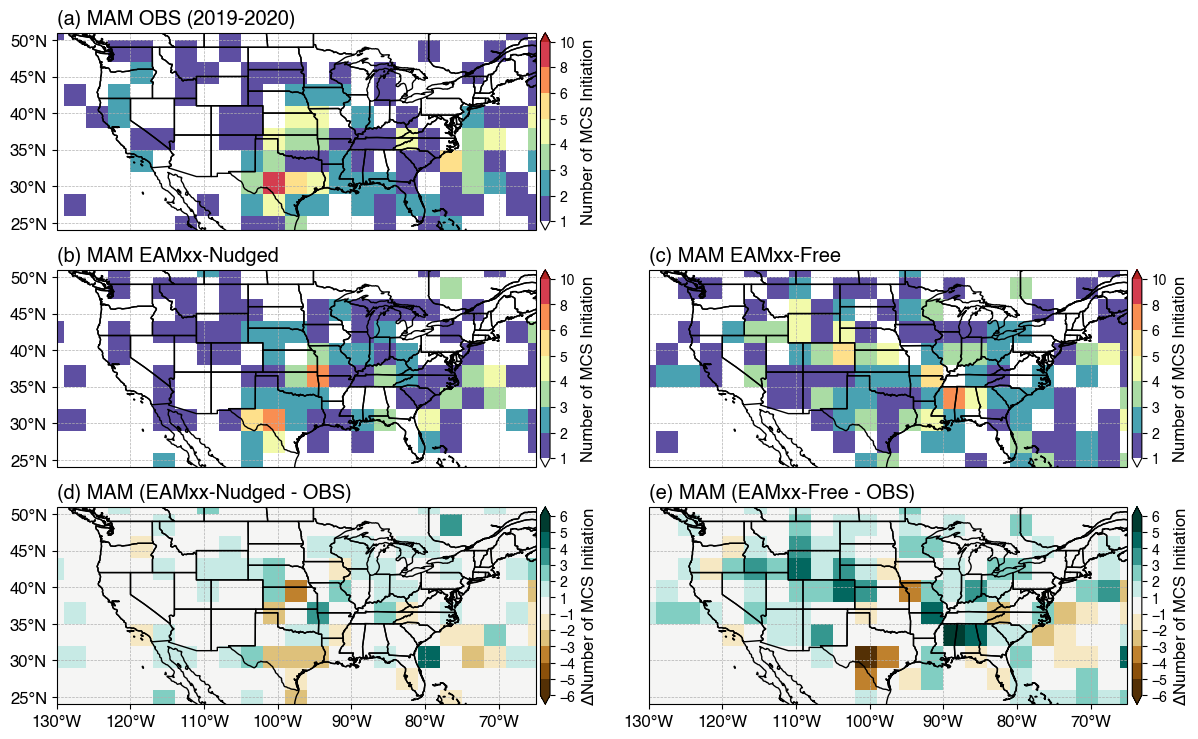

In [57]:
season = 'MAM'
mcs_initcount_diff1_MAM = mcs_initcount_m1_MAM - mcs_initcount_obs_MAM
mcs_initcount_diff2_MAM = mcs_initcount_m2_MAM - mcs_initcount_obs_MAM
dataarray = [
    [mcs_initcount_obs_MAM, None],
    [mcs_initcount_m1_MAM, mcs_initcount_m2_MAM],
    [mcs_initcount_diff1_MAM, mcs_initcount_diff2_MAM],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,6,8,10]
lev2 = np.arange(-6,6.1,1)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.9)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS Initiation']*ncol,['Number of MCS Initiation']*ncol,[r'$\Delta$'+'Number of MCS Initiation']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irinitiation_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
# oob_colors = None
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins_c, ybins_c, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irinitiation_map_annual_JJA_2019-2020.png


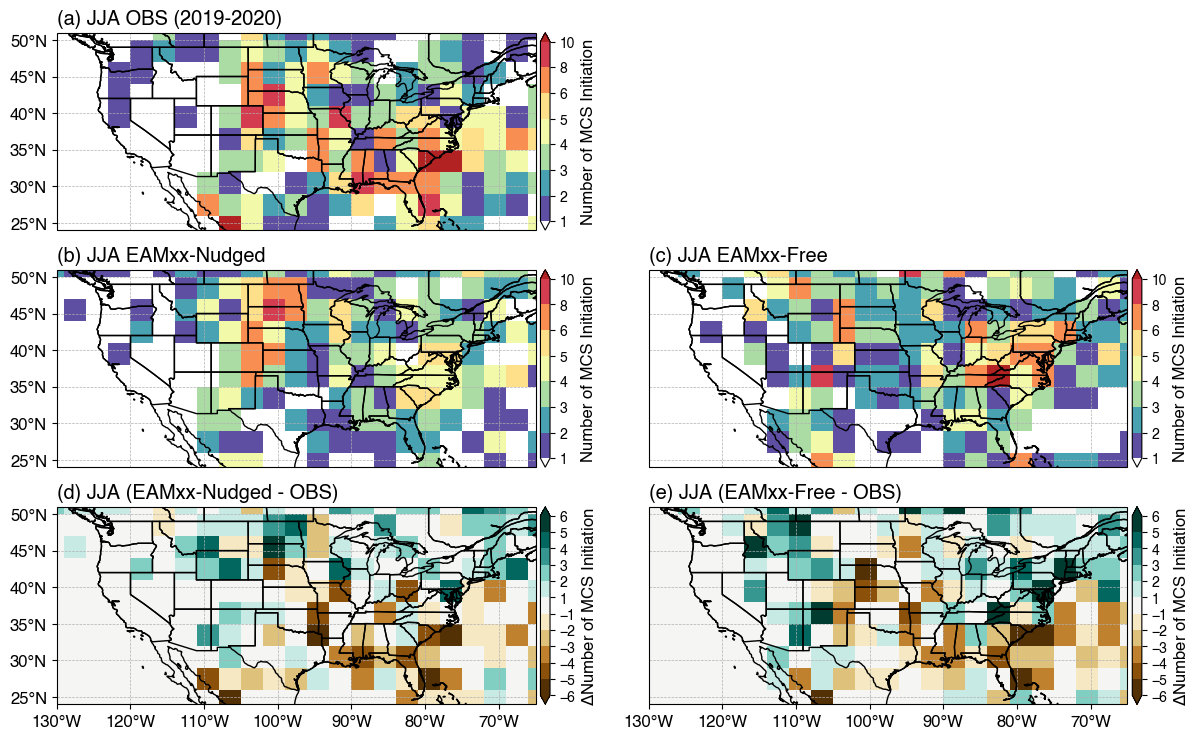

In [58]:
season = 'JJA'
mcs_initcount_diff1_JJA = mcs_initcount_m1_JJA - mcs_initcount_obs_JJA
mcs_initcount_diff2_JJA = mcs_initcount_m2_JJA - mcs_initcount_obs_JJA
dataarray = [
    [mcs_initcount_obs_JJA, None],
    [mcs_initcount_m1_JJA, mcs_initcount_m2_JJA],
    [mcs_initcount_diff1_JJA, mcs_initcount_diff2_JJA],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,6,8,10]
lev2 = np.arange(-6,6.1,1)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.9)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS Initiation']*ncol,['Number of MCS Initiation']*ncol,[r'$\Delta$'+'Number of MCS Initiation']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irinitiation_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
# oob_colors = None
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins_c, ybins_c, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/map_obs_scream_mcs_irinitiation_map_annual_SON_2019-2020.png


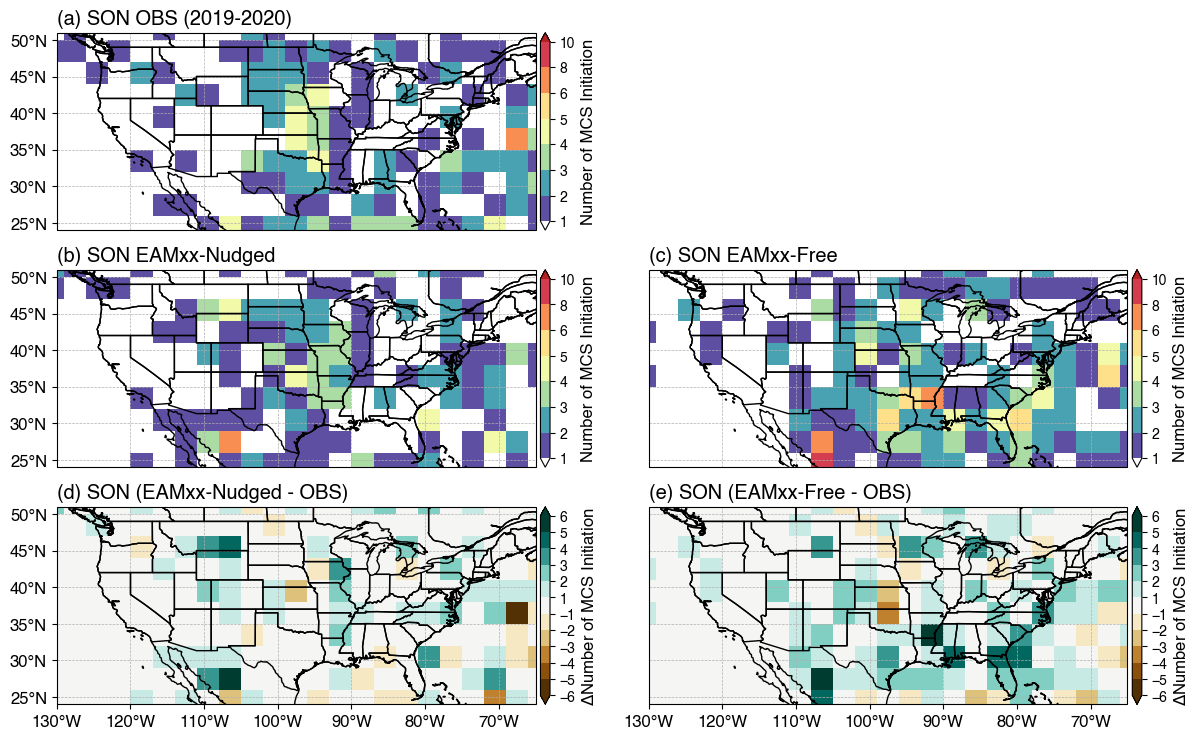

In [59]:
season = 'SON'
mcs_initcount_diff1_SON = mcs_initcount_m1_SON - mcs_initcount_obs_SON
mcs_initcount_diff2_SON = mcs_initcount_m2_SON - mcs_initcount_obs_SON
dataarray = [
    [mcs_initcount_obs_SON, None],
    [mcs_initcount_m1_SON, mcs_initcount_m2_SON],
    [mcs_initcount_diff1_SON, mcs_initcount_diff2_SON],
]
nrow = len(dataarray)
ncol = len(dataarray[0])

map_extent = [-130., -65., 24., 51.]
lonv = np.arange(-130,-65.1,10)
latv = np.arange(25,51.1,5)

figwidth = 14
height_ratio_per_panel = (map_extent[3] - map_extent[2]) / (map_extent[1] - map_extent[0])
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth,figheight]

# Set up contour levels and colormaps
lev1 = [1,2,3,4,5,6,8,10]
lev2 = np.arange(-6,6.1,1)
# Remove mid-point (0 value)
idx = int((len(lev2)-1)/2)
lev2 = np.delete(lev2, idx)
levels = [[lev1]*ncol, [lev1]*ncol, [lev2]*ncol]
cmap1 = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap1 = truncate_colormap(cmap1, 0.0, 0.9)
cmap2 = copy.copy(mpl.colormaps.get_cmap('BrBG'))
cmaps = [[cmap1]*ncol,[cmap1]*ncol,[cmap2]*ncol]
# Specify lat/lon labels
label_lon = [[False,False],[False,False],[True,True]]
label_lat = [[True,False],[True,False],[True,False]]

titles = [
    [f"(a) {season} {name_map1['obs']} ({years})", f"(b) {season} {name_map1['obs']} ({years})"], 
    [f"(b) {season} {name_map1['m1']}", f"(c) {season} {name_map1['m2']}"],
    [f"(d) {season} ({name_map1['m1']} - OBS)", f"(e) {season} ({name_map1['m2']} - OBS)"],
]
cblabels = [['Number of MCS Initiation']*ncol,['Number of MCS Initiation']*ncol,[r'$\Delta$'+'Number of MCS Initiation']*ncol]
cbticks = levels
figname = f'{figdir}map_obs_scream_mcs_irinitiation_map_annual_{season}_{years}.png'
oob_colors = [
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [{'under':'white', 'over':'firebrick'}]*ncol,
    [None]*ncol,
]
# oob_colors = None
fontsize = 12
cb_fontsize = 10
print(figname)

fig = plot_maps_mxn(nrow, ncol, dataarray, xbins_c, ybins_c, titles, levels, cmaps, cblabels, cbticks, figname, 
                    figsize=figsize, fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False, oob_colors=oob_colors, show_cb2=False,
                    map_extent=map_extent, lonv=lonv, latv=latv, label_lon=label_lon, label_lat=label_lat)